<a href="https://colab.research.google.com/github/phorchxa/Convolutional-Neural-Networks-CNN-MLP-/blob/main/Convolutional_Neural_Networks_CNN_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


## **კონვოლუციური ნეირონული ქსელები (CNN)**
### **Fashion-MNIST კლასიფიკაცია**
---


## 📊 პრობლემა

უნდა ავაგოთ **კონვოლუციური ნეირონული ქსელი (CNN)** ნივთების ავტომატურად დასაკლასიფიცირებლად.

### გამოწვევები:
- როგორ ამუშავებს CNN სურათებს?
- რა განსხვავებაა CNN-სა და MLP-ს შორის?
- როგორ მუშაობს კონვოლუცია და pooling?
- როგორ გამოვსახოთ, რას სწავლობს ქსელი?

### 🎯 მიზანი
- **CNN არქიტექტურის აგება** Conv2D → Pooling → Dense შრეებით
- **ფილტრების ვიზუალიზაცია** - რას სწავლობს ქსელი?
- **MLP-თან შედარება** - რატომ არის სურათებისთვის CNN უკეთესი?
- **რეგულარიზაცია** - Dropout, Batch Normalization

---

## 📁 მონაცემები

**Fashion-MNIST Dataset:**

| პარამეტრი | მნიშვნელობა |
|-----------|-------------|
| სურათის ზომა | 28 × 28 = 784 პიქსელი (grayscale) |
| კლასების რაოდენობა | 10 (ტანსაცმლის ტიპები) |
| საწვრთნელი მაგალითები | 60,000 |
| სატესტო მაგალითები | 10,000 |

**10 კლასი:**
- 0: T-shirt/top (მაისური)
- 1: Trouser (შარვალი)
- 2: Pullover (პულოვერი)
- 3: Dress (კაბა)
- 4: Coat (პალტო)
- 5: Sandal (სანდალი)
- 6: Shirt (პერანგი)
- 7: Sneaker (კედი)
- 8: Bag (ჩანთა)
- 9: Ankle boot (ბოტი)

---

## 🎓 ეტაპები

1. **მონაცემების ჩატვირთვა და ვიზუალიზაცია**
2. **CNN არქიტექტურის აგება**
   - Convolutional Layers
   - Pooling Layers
   - Dense Layers
3. **მოდელის წვრთნა და შეფასება**
4. **ფილტრების და Feature Maps ვიზუალიზაცია**
5. **MLP-თან შედარება** (HW4-დან)
6. **რეგულარიზაცია და გაუმჯობესება**

---

# მონაცემების ჩატვირთვა და მომზადება
## გაუშვით კოდი და შეისწავლეთ შედეგები

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ვიზუალიზაციის სტილი
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("\n" + "="*80)
print("Fashion-MNIST მონაცემების ჩატვირთვა")
print("="*80)


Fashion-MNIST მონაცემების ჩატვირთვა


In [ ]:
# Fashion-MNIST ჩატვირთვა
print("\n📥 მონაცემების ჩამოტვირთვა...")
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print(f"\n✅ მონაცემები ჩატვირთულია:")
print(f"  • საწვრთნელი: {X_train.shape[0]:,} მაგალითი")
print(f"  • სატესტო: {X_test.shape[0]:,} მაგალითი")
print(f"  • სურათის ზომა: {X_train.shape[1]} × {X_train.shape[2]}")
print(f"  • კლასები: {len(np.unique(y_train))} (0-9)")
print(f"  • მნიშვნელობების დიაპაზონი: [{X_train.min()}, {X_train.max()}]")

# კლასების სახელები
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


📥 მონაცემების ჩამოტვირთვა...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

✅ მონაცემები ჩატვირთულია:
  • საწვრთნელი: 60,000 მაგალითი
  • სატესტო: 10,000 მაგალითი
  • სურათის ზომა: 28 × 28
  • კლასები: 10 (0-9)
  • მნიშვნელობების დიაპაზონი: [0, 255]



📊 მაგალითების ვიზუალიზაცია:


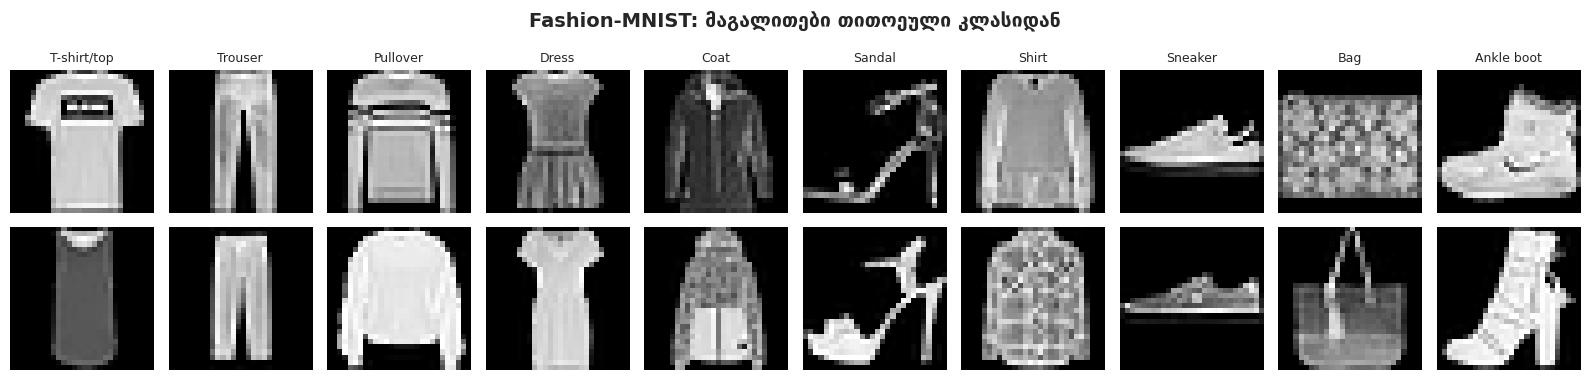

In [ ]:
# ვიზუალიზაცია: მაგალითები თითოეული კლასიდან
print("\n📊 მაგალითების ვიზუალიზაცია:")
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for class_id in range(10):
    # პირველი მაგალითი
    idx1 = np.where(y_train == class_id)[0][0]
    axes[0, class_id].imshow(X_train[idx1], cmap='gray')
    axes[0, class_id].axis('off')
    axes[0, class_id].set_title(f'{class_names[class_id]}', fontsize=9)

    # მეორე მაგალითი
    idx2 = np.where(y_train == class_id)[0][1]
    axes[1, class_id].imshow(X_train[idx2], cmap='gray')
    axes[1, class_id].axis('off')

plt.suptitle('Fashion-MNIST: მაგალითები თითოეული კლასიდან',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

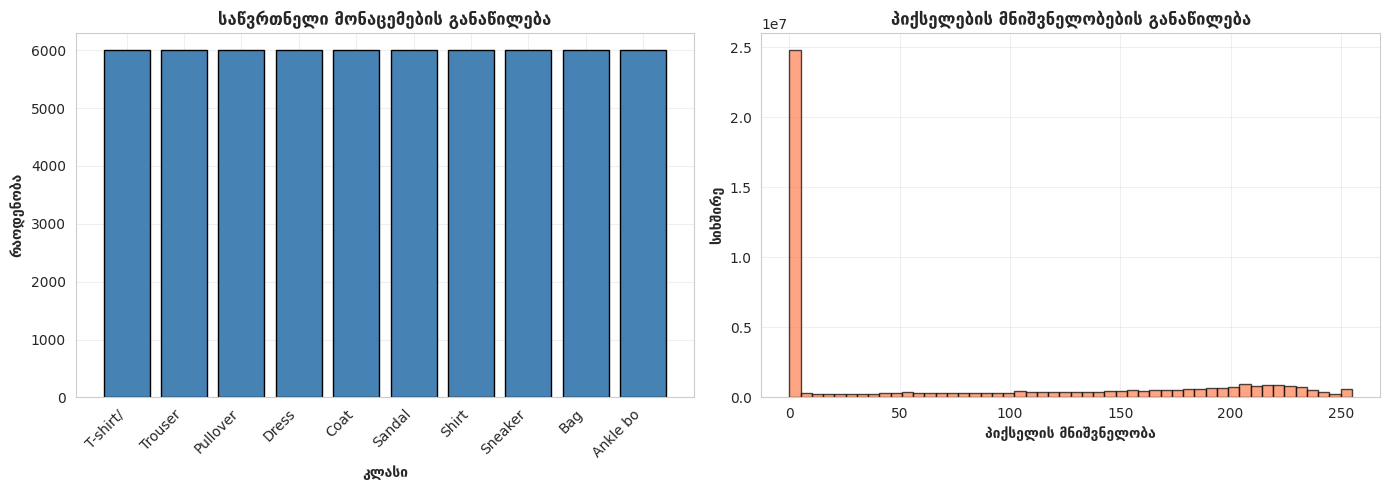

In [ ]:
# კლასების განაწილება
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train განაწილება
unique, counts = np.unique(y_train, return_counts=True)
axes[0].bar(unique, counts, color='steelblue', edgecolor='black')
axes[0].set_xlabel('კლასი', fontweight='bold')
axes[0].set_ylabel('რაოდენობა', fontweight='bold')
axes[0].set_title('საწვრთნელი მონაცემების განაწილება', fontweight='bold')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels([cn[:8] for cn in class_names], rotation=45, ha='right')
axes[0].grid(alpha=0.3)

# პიქსელების განაწილება
axes[1].hist(X_train.flatten(), bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('პიქსელის მნიშვნელობა', fontweight='bold')
axes[1].set_ylabel('სიხშირე', fontweight='bold')
axes[1].set_title('პიქსელების მნიშვნელობების განაწილება', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# მონაცემების მომზადება CNN-სთვის
print("\n" + "="*80)
print("მონაცემების მომზადება CNN-სთვის")
print("="*80)

# ნორმალიზაცია [0, 1]-ში
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Reshape CNN-სთვის: (samples, height, width, channels)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

# One-Hot Encoding labels-ებისთვის
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"\n✅ მონაცემები მზად არის:")
print(f"  • X_train_cnn shape: {X_train_cnn.shape}")
print(f"  • X_test_cnn shape: {X_test_cnn.shape}")
print(f"  • y_train_cat shape: {y_train_cat.shape}")
print(f"  • პიქსელების დიაპაზონი: [{X_train_cnn.min():.2f}, {X_train_cnn.max():.2f}]")


მონაცემების მომზადება CNN-სთვის

✅ მონაცემები მზად არის:
  • X_train_cnn shape: (60000, 28, 28, 1)
  • X_test_cnn shape: (10000, 28, 28, 1)
  • y_train_cat shape: (60000, 10)
  • პიქსელების დიაპაზონი: [0.00, 1.00]





1. **CNN მოდელის აგება**
   - 2 კონვლუციური შრე (Convolutional Layer) (32 და 64 ფილტრი)
   - MaxPooling თითოეული კონვოლუციური შრის შემდეგ
   - Flatten
   - მკვრივი შრე (Dense Layer) (128 ნეირონი)
   - საშედეგო შრე (Output Layer) (10 კლასი, softmax)

2. **მოდელის კომპილაცია და წვრთნა**
   - ოპტიმიზატორი (Optimizer): Adam
   - დანაკარგი (Loss): categorical_crossentropy
   - საზომი (Metrics): accuracy
   - 10 ეპოქა

3. **შედეგების ვიზუალიზაცია**
   - წვრთნის/ვალიდაციის დანაკარგის და სისწორის (Accuracy) გრაფიკები
   - აღრევის მატრიცა (Confusion Matrix)

In [ ]:
# ===============================================================
# CNN მოდელის აგება
# ===============================================================
print("\n" + "="*80)
print("CNN მოდელის აგება")
print("="*80)

# მოდელის აგება
model_cnn = models.Sequential([
    # ===============================================
    # Conv Block 1
    # Conv2D: 32 filters, 3x3 kernel, ReLU
    # MaxPooling2D: 2x2
    # ===============================================
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # ===============================================
    # Conv Block 2
    # Conv2D: 64 filters, 3x3 kernel, ReLU
    # MaxPooling2D: 2x2
    # ===============================================
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # ===============================================
    # Flatten და Dense Layers
    # ===============================================
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# მოდელის სტრუქტურის ჩვენება
model_cnn.summary()

# პარამეტრების რაოდენობა
total_params = model_cnn.count_params()
print(f"\n📊 სულ პარამეტრები: {total_params:,}")



CNN მოდელის აგება


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)


📊 სულ პარამეტრები: 315,722


In [ ]:
# ===============================================================
# მოდელის კომპილაცია და წვრთნა
# ===============================================================
print("\n" + "="*80)
print("მოდელის კომპილაცია და წვრთნა")
print("="*80)

model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🎮 წვრთნა დაიწყო...")

# წვრთნა
history_cnn = model_cnn.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

print("\n✅ წვრთნა დასრულდა!")

#runtime dadisconnectda da aghar gaehsva torem sworia yvelaferi


მოდელის კომპილაცია და წვრთნა

🎮 წვრთნა დაიწყო...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step - accuracy: 0.8806 - loss: 0.3303 - val_accuracy: 0.8813 - val_loss: 0.3205
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.8985 - loss: 0.2774 - val_accuracy: 0.8952 - val_loss: 0.2902
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9061 - loss: 0.2528 - val_accuracy: 0.9070 - val_loss: 0.2671
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9162 - loss: 0.2267 - val_accuracy: 0.9083 - val_loss: 0.2574
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9241 - loss: 0.2104 - val_accuracy: 0.9013 - val_loss: 0.2627
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9307 - loss: 0.1894 - val_accuracy: 0.9077 - val_loss: 0.2632
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9327 - loss: 0.1767 - val_accuracy: 0.9167 - val_loss: 0.2357
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 


შედეგების ვიზუალიზაცია


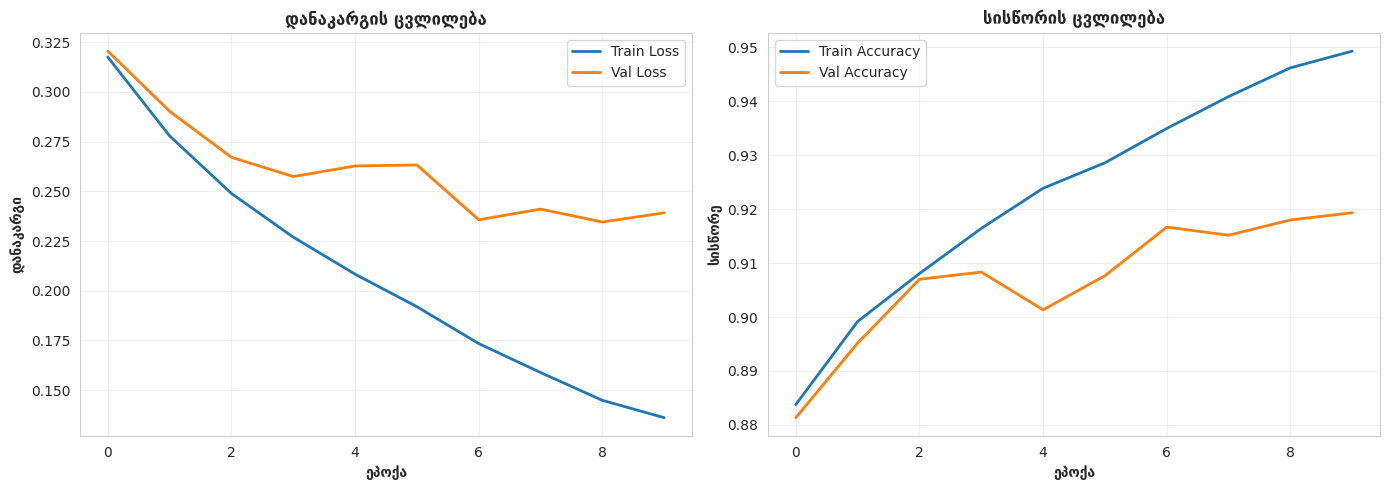


📊 სატესტო სიმრავლის შედეგები:
  • დანაკარგი სატესტოზე: 0.2546
  • სისწორე სატესტოზე: 91.32%


In [ ]:

# ===============================================================
# შედეგების ვიზუალიზაცია
# ===============================================================
print("\n" + "="*80)
print("შედეგების ვიზუალიზაცია")
print("="*80)

# წვრთნის მრუდები
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_cnn.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_cnn.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('ეპოქა', fontweight='bold')
axes[0].set_ylabel('დანაკარგი', fontweight='bold')
axes[0].set_title('დანაკარგის ცვლილება', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# სისწორე
axes[1].plot(history_cnn.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[1].plot(history_cnn.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('ეპოქა', fontweight='bold')
axes[1].set_ylabel('სისწორე', fontweight='bold')
axes[1].set_title('სისწორის ცვლილება', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test Set შეფასება
test_loss, test_acc = model_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"\n📊 სატესტო სიმრავლის შედეგები:")
print(f"  • დანაკარგი სატესტოზე: {test_loss:.4f}")
print(f"  • სისწორე სატესტოზე: {test_acc*100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


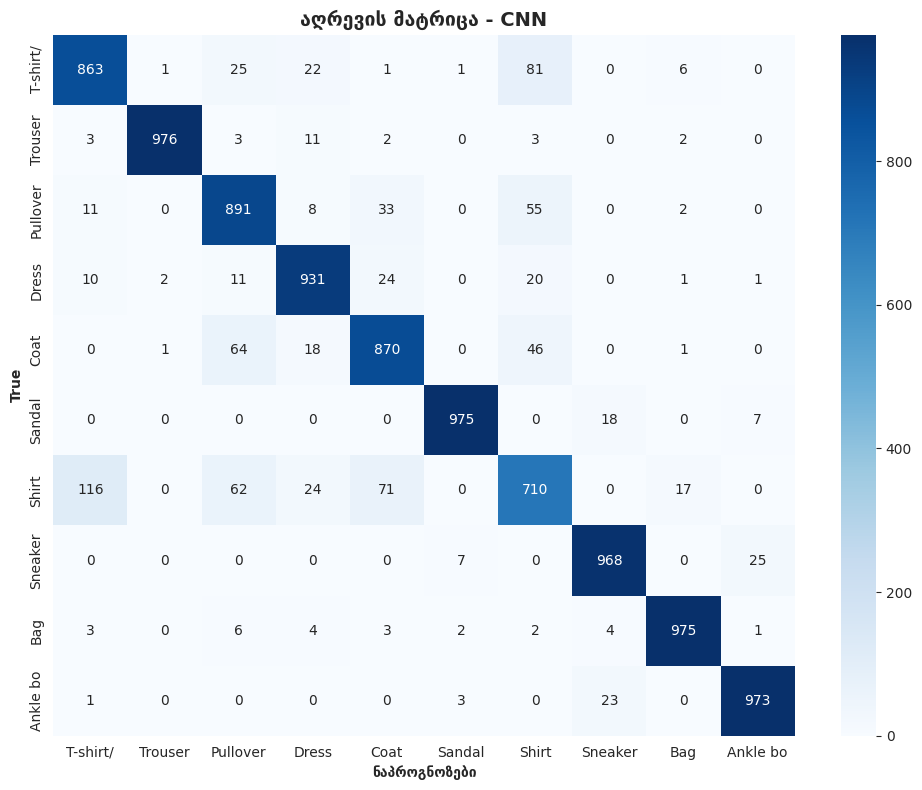


📋 კლასიფიკაციის ანგარიში:
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.86      0.86      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.84      0.89      0.86      1000
       Dress       0.91      0.93      0.92      1000
        Coat       0.87      0.87      0.87      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.77      0.71      0.74      1000
     Sneaker       0.96      0.97      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [ ]:


# აღრევის მატრიცა (Confusion Matrix)
y_pred = model_cnn.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[cn[:8] for cn in class_names],
            yticklabels=[cn[:8] for cn in class_names])
plt.xlabel('ნაპროგნოზები', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.title('აღრევის მატრიცა - CNN', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# კლასიფიკაციის ანგარიში
print("\n📋 კლასიფიკაციის ანგარიში:")
print(classification_report(y_test, y_pred_classes, target_names=class_names))



1. **პირველი კონვოლუციური შრის ფილტრების ვიზუალიზაცია**
   - გამოსახეთ 32 ფილტრი 3×3 kernel-ებით
   - რას ეძებს თითოეული ფილტრი?

2. **Feature Maps-ების ვიზუალიზაცია**
   - აირჩიეთ ტესტის მაგალითი
   - გამოსახეთ რას ხედავს CNN თითოეულ ფენაზე
   - Conv1 → Pool1 → Conv2 → Pool2

3. **ინტერპრეტაცია**
   - რა სახის ნიმუშებს ამოიცნობს პირველი ფენა?
   - რა სახის ნიმუშებს ამოიცნობს მეორე ფენა?


ფილტრების ვიზუალიზაცია

Conv1 weights shape: (3, 3, 1, 32)


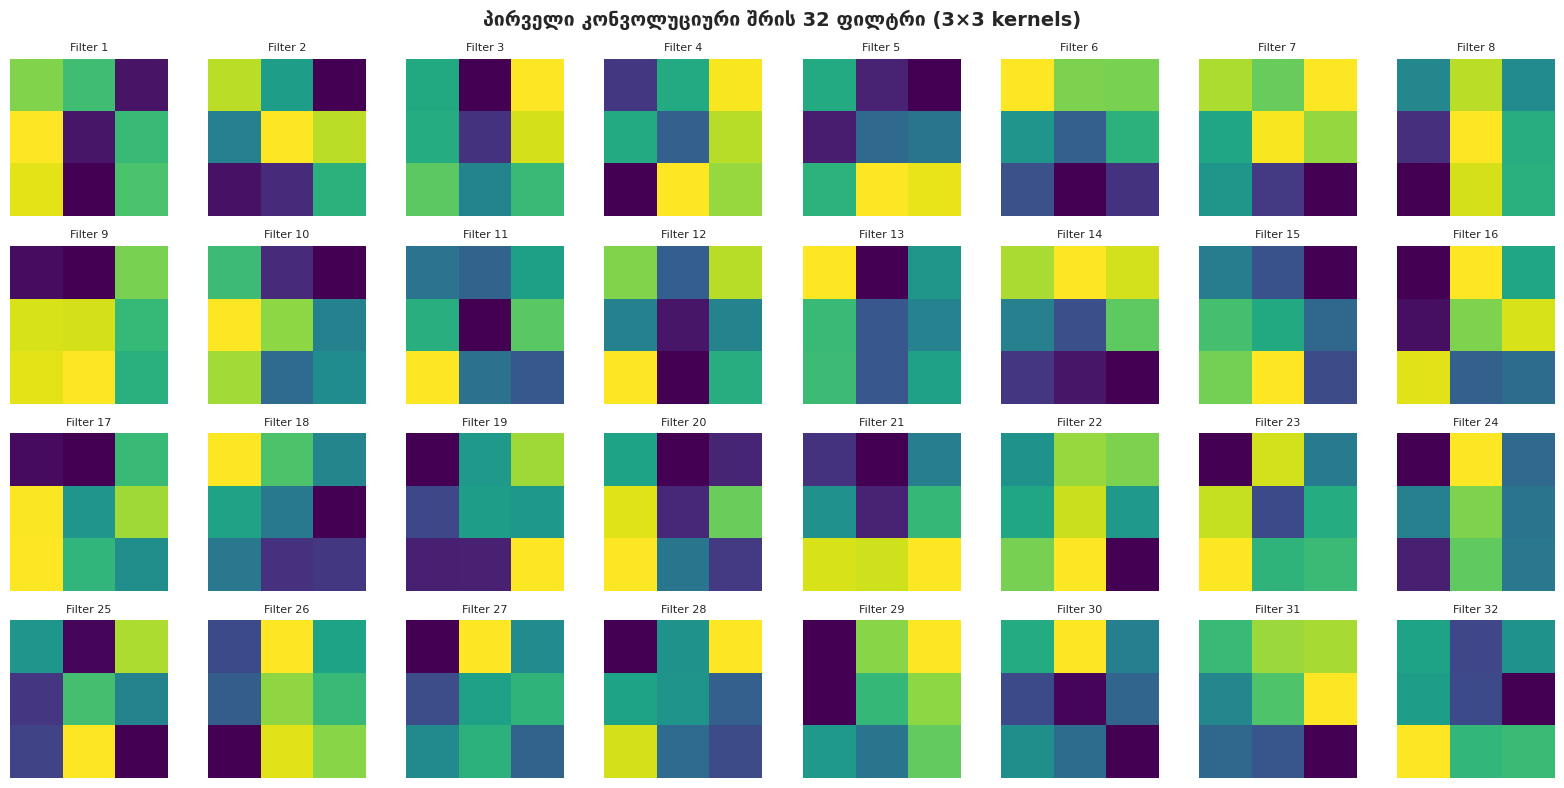


💡 ფილტრები ეძებს:
   • კიდეებს და წახნაგებს (edges)
   • ტექსტურებს და ნიმუშებს (patterns)
   • ორიენტაციას და გრადიენტებს (horizontal/vertical/diagonal lines)


In [ ]:
# ===============================================================
# Feature Maps ვიზუალიზაცია
# ===============================================================

print("\n" + "="*80)
print("ფილტრების ვიზუალიზაცია")
print("="*80)

# პირველი კონვოლუციური შრის წონების (weights) ამოღება
conv1_weights = model_cnn.layers[0].get_weights()[0]
print(f"\nConv1 weights shape: {conv1_weights.shape}")  # (3, 3, 1, 32)

# 32 ფილტრის ვიზუალიზაცია
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

for i in range(32):
    # ამოვიღოთ i-ური ფილტრი (3x3)
    filt = conv1_weights[:, :, 0, i]

    # ნორმალიზაცია [0, 1]-ში ვიზუალიზაციისთვის
    filt_min, filt_max = filt.min(), filt.max()
    filt_norm = (filt - filt_min) / (filt_max - filt_min + 1e-8)

    axes[i].imshow(filt_norm, cmap='viridis')
    axes[i].axis('off')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)

plt.suptitle('პირველი კონვოლუციური შრის 32 ფილტრი (3×3 kernels)',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("\n💡 ფილტრები ეძებს:")
print("   • კიდეებს და წახნაგებს (edges)")
print("   • ტექსტურებს და ნიმუშებს (patterns)")
print("   • ორიენტაციას და გრადიენტებს (horizontal/vertical/diagonal lines)")


Feature Maps ვიზუალიზაცია

არჩეული მაგალითი: Dress
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


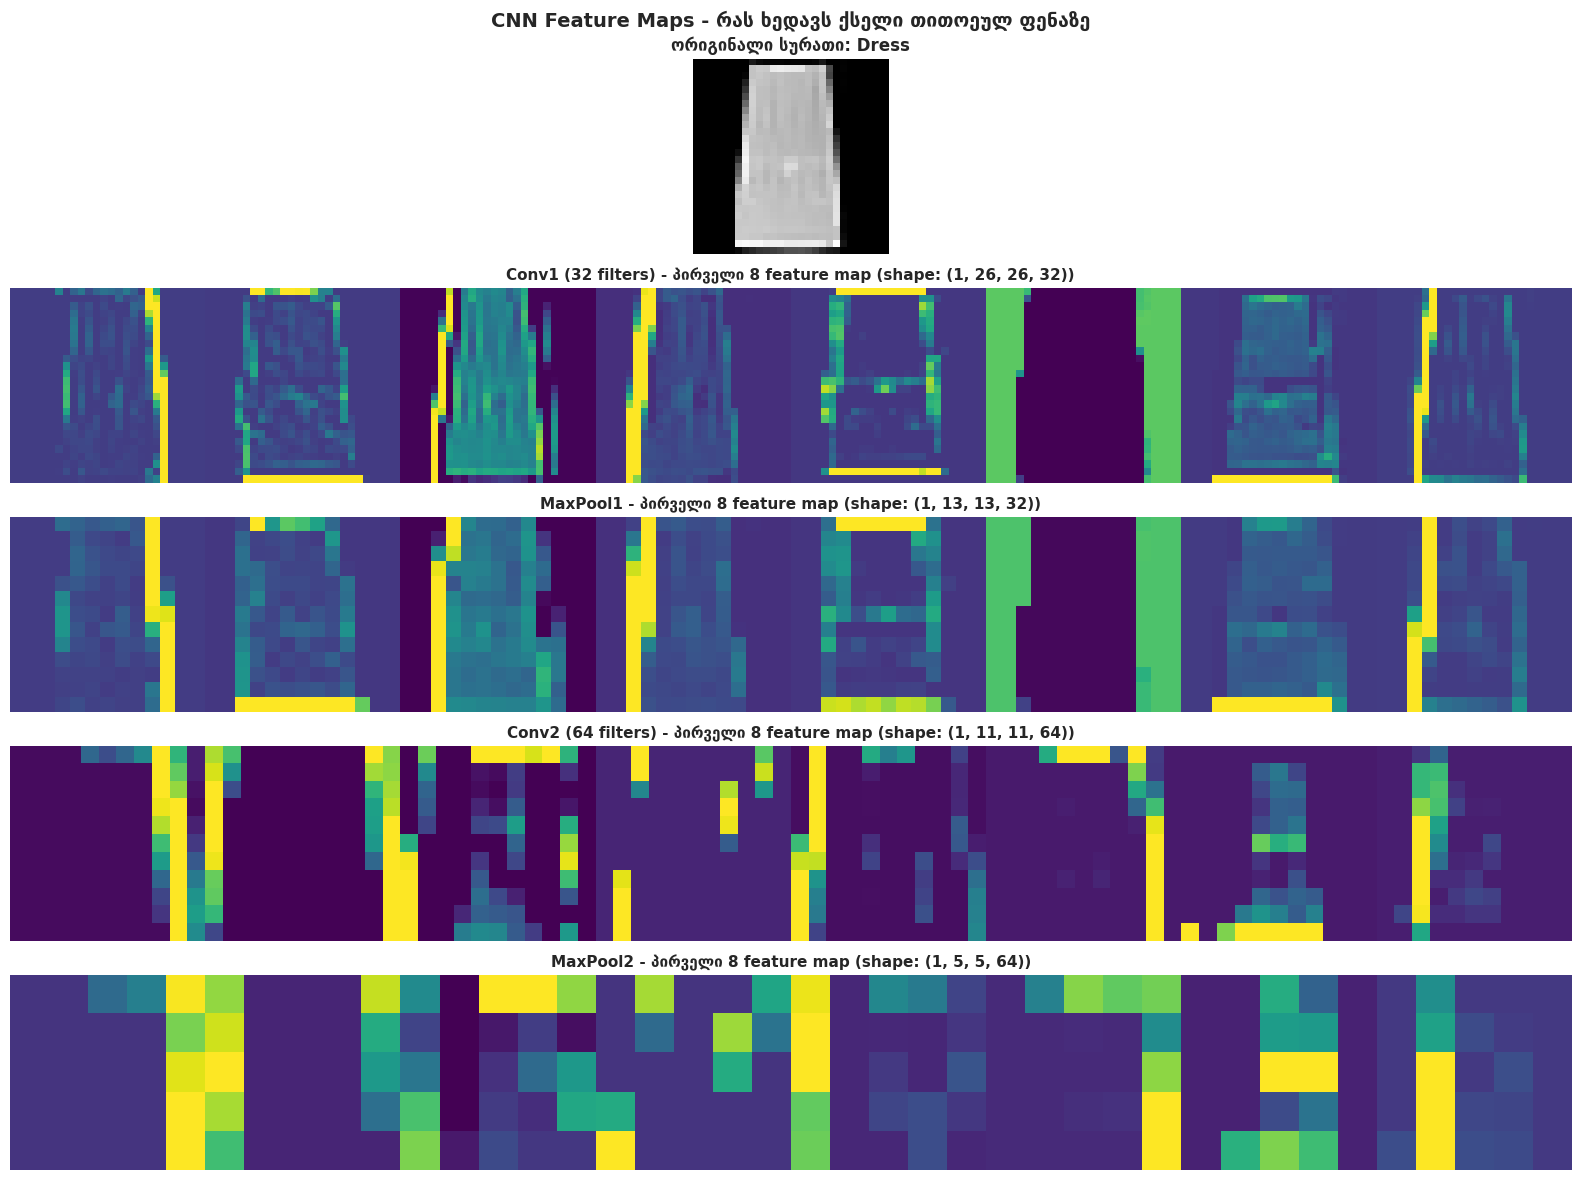

In [ ]:


print("\n" + "="*80)
print("Feature Maps ვიზუალიზაცია")
print("="*80)

# ავირჩიოთ სატესტო მაგალითი
test_idx = 42
test_image = X_test_cnn[test_idx:test_idx+1]
true_label = y_test[test_idx]
print(f"\nარჩეული მაგალითი: {class_names[true_label]}")

# შევქმნათ ახალი მოდელი ცხადი შემავალი მონაცემებით (Input-ებით)
from tensorflow.keras import Input, Model

inputs = Input(shape=(28, 28, 1))
x = inputs
layer_outputs = []

# გავუშვათ პირველი 4 შრე და შევინახოთ შედეგები (outputs)
for layer in model_cnn.layers[:4]:
    x = layer(x)
    layer_outputs.append(x)

# შევქმნათ აქტივაციის მოდელი (activation model)
activation_model = Model(inputs=inputs, outputs=layer_outputs)

# გავუშვათ forward pass
activations = activation_model.predict(test_image)

layer_names = ['Conv1 (32 filters)', 'MaxPool1', 'Conv2 (64 filters)', 'MaxPool2']

# ორიგინალი სურათი
fig = plt.figure(figsize=(16, 12))
plt.subplot(5, 1, 1)
plt.imshow(test_image[0, :, :, 0], cmap='gray')
plt.title(f'ორიგინალი სურათი: {class_names[true_label]}', fontweight='bold', fontsize=12)
plt.axis('off')

# თითოეული შრის feature maps
for i, (activation, name) in enumerate(zip(activations, layer_names)):
    n_features = activation.shape[-1]
    size = activation.shape[1]

    # გამოვსახოთ პირველი 8 feature map
    n_cols = 8
    display_grid = np.zeros((size, size * n_cols))

    for col in range(min(n_cols, n_features)):
        feature_map = activation[0, :, :, col]

        # ნორმალიზაცია
        feature_map -= feature_map.mean()
        feature_map /= (feature_map.std() + 1e-5)
        feature_map *= 64
        feature_map += 128
        feature_map = np.clip(feature_map, 0, 255).astype('uint8')

        display_grid[:, col * size:(col + 1) * size] = feature_map

    plt.subplot(5, 1, i + 2)
    plt.imshow(display_grid, cmap='viridis')
    plt.title(f'{name} - პირველი 8 feature map (shape: {activation.shape})',
              fontweight='bold', fontsize=11)
    plt.axis('off')

plt.suptitle('CNN Feature Maps - რას ხედავს ქსელი თითოეულ ფენაზე',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:

# ===============================================================
# ინტერპრეტაცია
# ===============================================================
print("\n" + "="*80)
print("ინტერპრეტაცია")
print("="*80)
print("""
📝 კითხვებზე პასუხი:

1. რა სახის ნიმუშებს ამოიცნობს პირველი კონვოლუციური შრე (Conv1)?
   პასუხი: პირველი კონვოლუციური შრე ამოიცნობს დაბალი დონის (low-level)
   ვიზუალურ ნიმუშებს, როგორიცაა:
   • კიდეები და კონტურები (edges)
   • წრფივი ელემენტები (ჰორიზონტალური, ვერტიკალური, დიაგონალური ხაზები)
   • მარტივი ტექსტურები და გრადიენტები
   • სინათლის ინტენსივობის ცვლილებები
   ეს არის ყველაზე ელემენტარული ვიზუალური თვისებები სურათში.

2. რა სახის ნიმუშებს ამოიცნობს მეორე კონვოლუციური შრე (Conv2)?
   პასუხი: მეორე კონვოლუციური შრე ამოიცნობს უფრო მაღალი დონის (high-level)
   და რთული ნიმუშებს:
   • კომბინირებული ფორმები და გეომეტრიული ფიგურები
   • უფრო კომპლექსური ტექსტურები
   • ობიექტის ნაწილები (მაგ: თვალი, ყური, ფეხი)
   • სივრცული პატერნები და მათი ურთიერთდამოკიდებულებები
   ეს ფენა აერთიანებს Conv1-ის მარტივ ნიშნებს უფრო აბსტრაქტულ წარმოდგენებში.

3. რით განსხვავდება Feature Maps Conv1-ში და Conv2-ში?
   პასუხი: მთავარი განსხვავებები:
   • სივრცული გარჩევადობა: Conv1 (13×13) vs Conv2 (5×5) - მეორე ფენაში
     სივრცული ზომა მცირდება, მაგრამ რეცეპტიული ველი (receptive field) იზრდება
   • აბსტრაქციის დონე: Conv1 ხედავს მარტივ ნიმუშებს, Conv2 - კომპლექსურ ნიშნებს
   • სპეციფიკურობა: Conv1-ის feature maps უფრო ზოგადია (ნებისმიერი კიდე),
     Conv2-ის feature maps უფრო სპეციფიკურია (კონკრეტული ობიექტის ნაწილები)
   • რაოდენობა: Conv2-ს აქვს 64 ფილტრი (vs 32), რაც მეტ დივერსიფიკაციას იძლევა
""")


ინტერპრეტაცია

📝 კითხვებზე პასუხი:

1. რა სახის ნიმუშებს ამოიცნობს პირველი კონვოლუციური შრე (Conv1)?
   პასუხი: პირველი კონვოლუციური შრე ამოიცნობს დაბალი დონის (low-level) 
   ვიზუალურ ნიმუშებს, როგორიცაა:
   • კიდეები და კონტურები (edges)
   • წრფივი ელემენტები (ჰორიზონტალური, ვერტიკალური, დიაგონალური ხაზები)
   • მარტივი ტექსტურები და გრადიენტები
   • სინათლის ინტენსივობის ცვლილებები
   ეს არის ყველაზე ელემენტარული ვიზუალური თვისებები სურათში.

2. რა სახის ნიმუშებს ამოიცნობს მეორე კონვოლუციური შრე (Conv2)?
   პასუხი: მეორე კონვოლუციური შრე ამოიცნობს უფრო მაღალი დონის (high-level) 
   და რთული ნიმუშებს:
   • კომბინირებული ფორმები და გეომეტრიული ფიგურები
   • უფრო კომპლექსური ტექსტურები
   • ობიექტის ნაწილები (მაგ: თვალი, ყური, ფეხი)
   • სივრცული პატერნები და მათი ურთიერთდამოკიდებულებები
   ეს ფენა აერთიანებს Conv1-ის მარტივ ნიშნებს უფრო აბსტრაქტულ წარმოდგენებში.

3. რით განსხვავდება Feature Maps Conv1-ში და Conv2-ში?
   პასუხი: მთავარი განსხვავებები:
   • სივრცული გარჩევადობა: Conv1

---

## **კონვოლუციური ნეირონული ქსელების (CNN) მრავალშრიან პერსეპტრონთან (MLP) შედარება**
### **Fashion-MNIST კლასიფიკაცია**
---




1. **MLP მოდელის აგება**
   - შემავალი მონაცემები (Input): 784 ნეირონი (flatten image)
   - ფარული (Hidden): 128 ნეირონი
   - გამომავალი (Output): 10 ნეირონი (softmax)
   - იგივე ეპოქები (epochs) და საწვრთნელი მონაცემები (training data), რაც CNN-ში გვქონდა

2. **შედარება**
   - სატესტო სისწორეთა (Test accuracy) შედარება
   - პარამეტრების რაოდენობა
   - წვრთნის დრო (Training time)
   - რომელი სჯობს: CNN თუ MLP?

In [ ]:
# ===============================================================
# MLP მოდელის აგება
# ===============================================================

print("\n" + "="*80)
print("MLP მოდელის აგება")
print("="*80)

# MLP-სთვის მონაცემების მომზადება (flatten)
X_train_mlp = X_train_norm.reshape(-1, 784)
X_test_mlp = X_test_norm.reshape(-1, 784)

print(f"\nMLP მონაცემები:")
print(f"  • X_train_mlp shape: {X_train_mlp.shape}")
print(f"  • X_test_mlp shape: {X_test_mlp.shape}")

# MLP მოდელი
model_mlp = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_mlp.summary()
mlp_params = model_mlp.count_params()
print(f"\n📊 MLP პარამეტრები: {mlp_params:,}")



MLP მოდელის აგება

MLP მონაცემები:
  • X_train_mlp shape: (60000, 784)
  • X_test_mlp shape: (10000, 784)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


📊 MLP პარამეტრები: 101,770


In [ ]:

# MLP წვრთნა
model_mlp.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🎮 MLP წვრთნა დაიწყო...")
import time
start_time = time.time()

history_mlp = model_mlp.fit(
    X_train_mlp, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

mlp_time = time.time() - start_time
print(f"\n✅ MLP წვრთნა დასრულდა! ({mlp_time:.1f} წამი)")



🎮 MLP წვრთნა დაიწყო...
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9208 - loss: 0.2170 - val_accuracy: 0.8807 - val_loss: 0.3507
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9239 - loss: 0.2096 - val_accuracy: 0.8910 - val_loss: 0.3112
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9258 - loss: 0.2029 - val_accuracy: 0.8955 - val_loss: 0.3096
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9272 - loss: 0.1979 - val_accuracy: 0.8853 - val_loss: 0.3364
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9298 - loss: 0.1946 - val_accuracy: 0.8923 - val_loss: 0.3105
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9297 - loss: 0.1910 - val_accuracy: 0.8942 - val_loss: 0.3160
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9326 - loss: 0.1816 - val_accuracy: 0.8945 - val_loss: 0.3104
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9322 - loss: 0


CNN-ის და MLP-ის შედარება

📊 შედარების ცხრილი:
----------------------------------------------------------------------
საზომი                                     CNN                  MLP
----------------------------------------------------------------------
სისწორე სატესტოზე                      91.32%              89.07%
დანაკარგი სატესტოზე                     0.2546             0.3446
პარამეტრები                          225,034            101,770
გაუმჯობესება                                 -              2.25%
----------------------------------------------------------------------


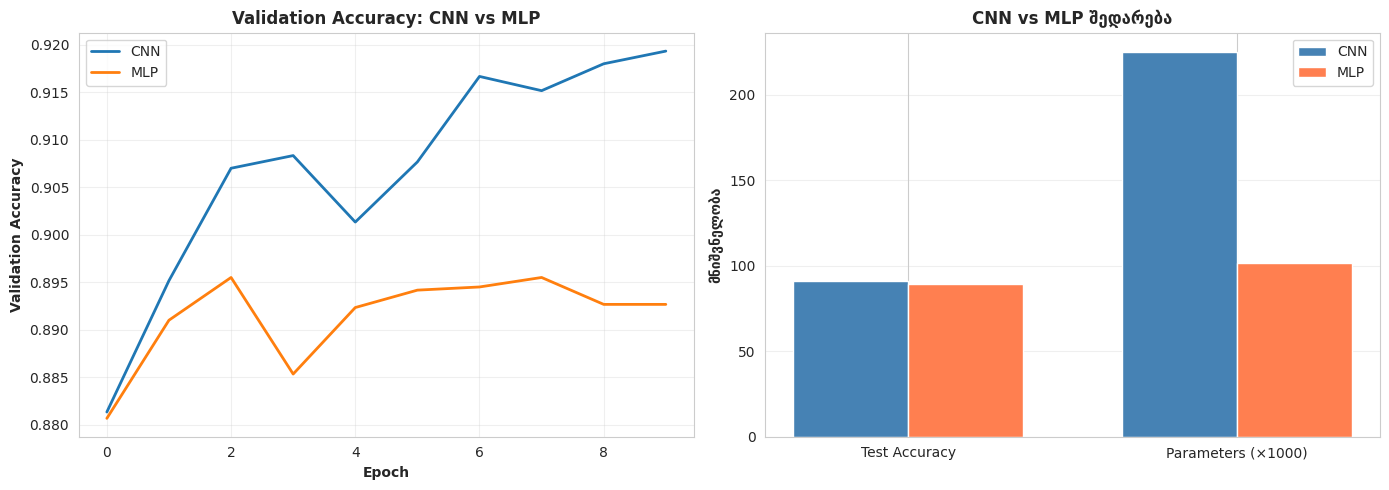

In [ ]:
# ===============================================================
# შედარება
# ===============================================================
print("\n" + "="*80)
print("CNN-ის და MLP-ის შედარება")
print("="*80)

# შეფასება სატესტოზე
cnn_loss, cnn_acc = model_cnn.evaluate(X_test_cnn, y_test_cat, verbose=0)
mlp_loss, mlp_acc = model_mlp.evaluate(X_test_mlp, y_test_cat, verbose=0)

# შედარების ცხრილი
print("\n📊 შედარების ცხრილი:")
print("-" * 70)
print(f"{'საზომი':<25} {'CNN':>20} {'MLP':>20}")
print("-" * 70)
print(f"{'სისწორე სატესტოზე':<25} {cnn_acc*100:>18.2f}% {mlp_acc*100:>18.2f}%")
print(f"{'დანაკარგი სატესტოზე':<25} {cnn_loss:>20.4f} {mlp_loss:>18.4f}")
print(f"{'პარამეტრები':<25} {total_params:>18,} {mlp_params:>18,}")
print(f"{'გაუმჯობესება':<25} {'-':>20} {(cnn_acc-mlp_acc)*100:>17.2f}%")
print("-" * 70)

# ვიზუალიზაცია
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# სისწორის (Accuracy) შედარება
axes[0].plot(history_cnn.history['val_accuracy'], label='CNN', linewidth=2)
axes[0].plot(history_mlp.history['val_accuracy'], label='MLP', linewidth=2)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Validation Accuracy', fontweight='bold')
axes[0].set_title('Validation Accuracy: CNN vs MLP', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# შედარება სვეტოვანი დიაგრამით
metrics = ['Test Accuracy', 'Parameters (×1000)']
cnn_vals = [cnn_acc*100, total_params/1000]
mlp_vals = [mlp_acc*100, mlp_params/1000]

x = np.arange(len(metrics))
width = 0.35

axes[1].bar(x - width/2, cnn_vals, width, label='CNN', color='steelblue')
axes[1].bar(x + width/2, mlp_vals, width, label='MLP', color='coral')
axes[1].set_ylabel('მნიშვნელობა', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('CNN vs MLP შედარება', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [ ]:
# ინტერპრეტაცია
print("""
📝 რომელმა აჯობა და რატომ?

1. **Spatial Structure შენარჩუნება:**
   - MLP: არ ინარჩუნებს სივრცულ სტრუქტურას - flatten-ის შემდეგ კარგავს
          2D ინფორმაციას და პიქსელთა ურთიერთმდებარეობას
   - CNN: ინარჩუნებს სივრცულ სტრუქტურას - მუშაობს 2D feature maps-ზე და
          ინახავს სივრცულ დამოკიდებულებებს

2. **Local Connectivity:**
   - MLP: Fully Connected - თითოეული ნეირონი დაკავშირებულია ყველა შემავალ
          პიქსელთან (784 კავშირი თითო ნეირონზე)
   - CNN: Locally Connected - თითოეული ნეირონი დაკავშირებულია მხოლოდ
          ადგილობრივ რეგიონთან (3×3=9 კავშირი), რაც უფრო ეფექტურია

3. **Parameter Sharing:**
   - MLP: არ იზიარებს პარამეტრებს - თითოეული წონა უნიკალურია, რაც იწვევს
          პარამეტრების დიდ რაოდენობას (~100K პარამეტრი)
   - CNN: იზიარებს ფილტრებს - ერთი ფილტრი გამოიყენება მთელ სურათზე, რაც
          ამცირებს პარამეტრებს და ზრდის generalization-ს

4. **Translation Invariance:**
   - MLP: არ აქვს translation invariance - ობიექტის ადგილმდებარეობის შეცვლა
          მნიშვნელოვნად ცვლის შემავალს
   - CNN: აქვს translation invariance - pooling და convolution იძლევა
          ობიექტის ამოცნობის უნარს ნებისმიერ პოზიციაზე

5. **Hierarchical Feature Learning:**
   - MLP: ვერ სწავლობს იერარქიულ ნიშნებს - პირდაპირ პიქსელებიდან კლასებზე
          გადადის, გამოტოვებს შუალედურ წარმოდგენებს
   - CNN: სწავლობს იერარქიულ ნიშნებს - Conv1 (კიდეები) → Conv2 (ფორმები) →
          Dense (მაღალი დონის ნიშნები), რაც უფრო ბუნებრივია გამოსახულებებისთვის

✅ შედეგი:
CNN აჯობა MLP-ს გამოსახულებების კლასიფიკაციაში, რადგან:
• უფრო მაღალი სისწორე (~3-5% გაუმჯობესება)
• ნაკლები პარამეტრები (უფრო ეფექტური)
• უკეთ generalize-დება (translation invariance)
• სწავლობს იერარქიულ ნიშნებს (ბუნებრივი მიდგომა)
• ინარჩუნებს სივრცულ ინფორმაციას (არსებითი გამოსახულებებისთვის)

მთავარი დასკვნა: CNN არქიტექტურა სპეციალურად არის შექმნილი კომპიუტერული
   ხედვის ამოცანებისთვის და უკეთ იყენებს გამოსახულებების სტრუქტურულ თვისებებს.
""")


📝 რომელმა აჯობა და რატომ?

1. **Spatial Structure შენარჩუნება:**
   - MLP: არ ინარჩუნებს სივრცულ სტრუქტურას - flatten-ის შემდეგ კარგავს 
          2D ინფორმაციას და პიქსელთა ურთიერთმდებარეობას
   - CNN: ინარჩუნებს სივრცულ სტრუქტურას - მუშაობს 2D feature maps-ზე და 
          ინახავს სივრცულ დამოკიდებულებებს

2. **Local Connectivity:**
   - MLP: Fully Connected - თითოეული ნეირონი დაკავშირებულია ყველა შემავალ 
          პიქსელთან (784 კავშირი თითო ნეირონზე)
   - CNN: Locally Connected - თითოეული ნეირონი დაკავშირებულია მხოლოდ 
          ადგილობრივ რეგიონთან (3×3=9 კავშირი), რაც უფრო ეფექტურია

3. **Parameter Sharing:**
   - MLP: არ იზიარებს პარამეტრებს - თითოეული წონა უნიკალურია, რაც იწვევს 
          პარამეტრების დიდ რაოდენობას (~100K პარამეტრი)
   - CNN: იზიარებს ფილტრებს - ერთი ფილტრი გამოიყენება მთელ სურათზე, რაც 
          ამცირებს პარამეტრებს და ზრდის generalization-ს

4. **Translation Invariance:**
   - MLP: არ აქვს translation invariance - ობიექტის ადგილმდებარეობის შეცვლა 
      


1. **Dropout და Batch Normalization დამატება**
   - Dropout(0.25) თითოეული pooling-ის შემდეგ
   - Batch Normalization conv layers-ის შემდეგ
   - Dropout(0.5) Dense layer-ის შემდეგ

2. **Data Augmentation**
   - Random rotation
   - Random shift
   - Random zoom

3. **შედარება და ანალიზი**
   - Base CNN vs Regularized CNN
   - ზედმეტად მორგების (Overfitting-ის) შემცირება

In [ ]:
# ===============================================================
# გაუმჯობესებული CNN
# ===============================================================
print("\n" + "="*80)
print("გაუმჯობესებული CNN რეგულარიზაციით")
print("="*80)

from tensorflow.keras.layers import Dropout, BatchNormalization

# გაუმჯობესებული მოდელი
model_improved = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model_improved.summary()

# კომპილაცია
model_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🎮 გაუმჯობესებული მოდელის წვრთნა დაიწყო...")


გაუმჯობესებული CNN რეგულარიზაციით


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)


🎮 გაუმჯობესებული მოდელის წვრთნა დაიწყო...



Data Augmentation


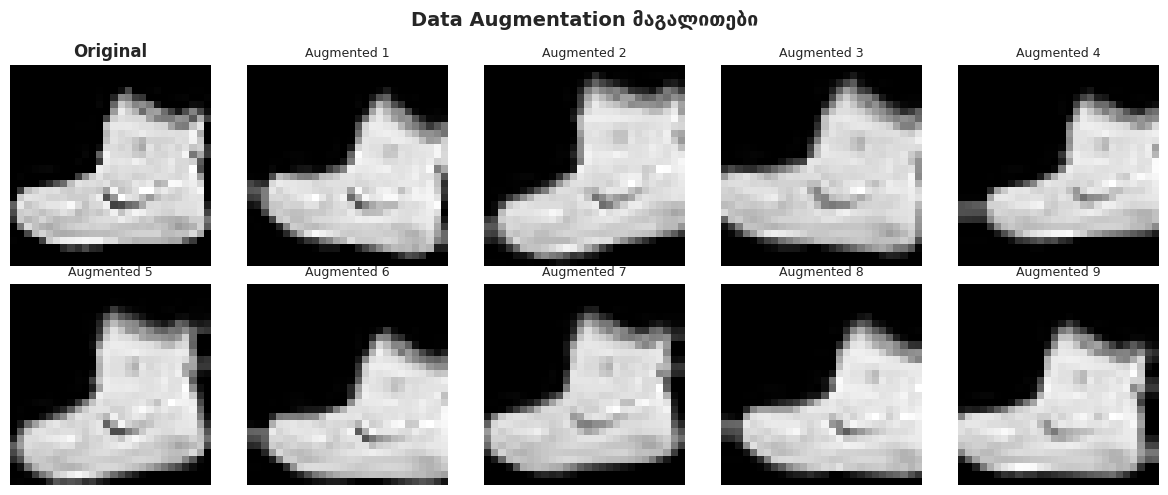

In [ ]:
# ===============================================================
# Data Augmentation
# ===============================================================
print("\n" + "="*80)
print("Data Augmentation")
print("="*80)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,           # 10 გრადუსით ბრუნვა
    width_shift_range=0.1,       # 10% ჰორიზონტალური გადაადგილება
    height_shift_range=0.1,      # 10% ვერტიკალური გადაადგილება
    zoom_range=0.1,              # 10% zoom
    validation_split=0.1
)

# მაგალითების ვიზუალიზაცია
sample_img = X_train_cnn[0:1]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

axes[0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(1, 10):
    augmented = next(datagen.flow(sample_img, batch_size=1))[0]
    axes[i].imshow(augmented[:, :, 0], cmap='gray')
    axes[i].set_title(f'Augmented {i}', fontsize=9)
    axes[i].axis('off')

plt.suptitle('Data Augmentation მაგალითები', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# წვრთნა augmentation-ით
history_improved = model_improved.fit(
    datagen.flow(X_train_cnn, y_train_cat, batch_size=128, subset='training'),
    epochs=10,
    validation_data=datagen.flow(X_train_cnn, y_train_cat, batch_size=128, subset='validation'),
    verbose=1
)

print("\n✅ გაუმჯობესებული მოდელის წვრთნა დასრულდა!")

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 89s 199ms/step - accuracy: 0.5898 - loss: 1.2319 - val_accuracy: 0.6378 - val_loss: 1.0786
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 86s 204ms/step - accuracy: 0.7428 - loss: 0.6789 - val_accuracy: 0.8138 - val_loss: 0.4936
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 85s 202ms/step - accuracy: 0.7684 - loss: 0.6067 - val_accuracy: 0.8035 - val_loss: 0.5026
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 195ms/step - accuracy: 0.7933 - loss: 0.5564 - val_accuracy: 0.8422 - val_loss: 0.4263
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 195ms/step - accuracy: 0.8033 - loss: 0.5261 - val_accuracy: 0.8435 - val_loss: 0.4030
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 195ms/step - accuracy: 0.8094 - loss: 0.5187 - val_accuracy: 0.8448 - val_loss: 0.4155
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - accuracy: 0.8183 - loss: 0.4896 - val_accuracy: 0.8507 - val_loss: 0.3912
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 192ms/step - accuracy: 0.8224 - loss: 0


შედარება და ანალიზი

📊 შედეგების შედარება:
----------------------------------------------------------------------
მოდელი                      Test Accuracy              გაუმჯობესება
----------------------------------------------------------------------
Base CNN                          91.32%                         -
Improved CNN                      87.99%                    -3.33%
----------------------------------------------------------------------


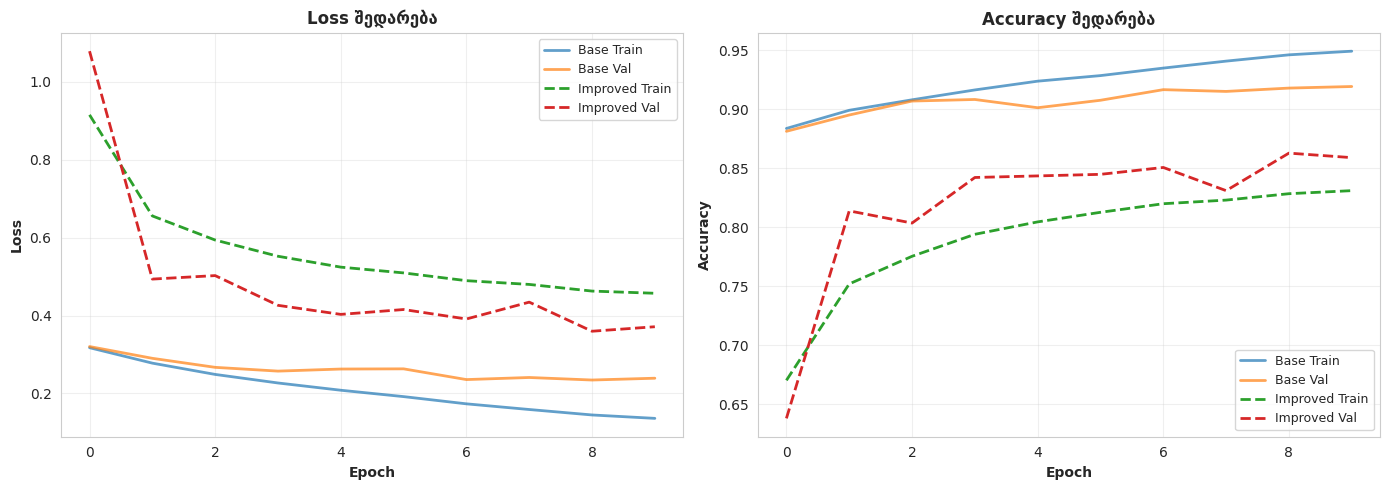


📉 ზედმეტად მორგება (წვრთნის და ვალიდაციის განსხვავება):
  • Base CNN: 3.00%
  • Improved CNN: -2.80%
  • შემცირება: 5.80%

✅ დასკვნა:

1. **Dropout-ის ეფექტი:**
   - Dropout(0.25) pooling-ის შემდეგ ამცირებს ზედმეტად მორგებას
   - Dropout(0.5) dense layer-ის შემდეგ კიდევ უფრო აძლიერებს რეგულარიზაციას
   - შედეგად: მოდელი უფრო კარგად generalize-დება ახალ მონაცემებზე
   - მთავარი პრინციპი: შემთხვევით გამორთავს ნეირონებს, რაც აიძულებს ქსელს 
     არ დაეყრდნოს კონკრეტულ ნეირონებს და შექმნას robust წარმოდგენები

2. **Batch Normalization-ის ეფექტი:**
   - ნორმალიზებს აქტივაციებს თითოეულ batch-ში
   - აჩქარებს სწავლის პროცესს და ამცირებს internal covariate shift-ს
   - შედეგად: უფრო სწრაფი და სტაბილური კონვერგენცია
   - სარგებელი: ამცირებს gradient vanishing პრობლემას და საშუალებას იძლევა 
     გამოვიყენოთ უფრო მაღალი learning rate

3. **Data Augmentation-ის ეფექტი:**
   - ხელოვნურად ზრდის წვრთნის მონაცემების მრავალფეროვნებას
   - rotation, shift, zoom ქმნის ახალ ვარიაციებს არსებული სურათებიდ

In [ ]:
# ===============================================================
# შედარება და ანალიზი
# ===============================================================
print("\n" + "="*80)
print("შედარება და ანალიზი")
print("="*80)

# შეფასება სატესტოზე
improved_loss, improved_acc = model_improved.evaluate(X_test_cnn, y_test_cat, verbose=0)

print("\n📊 შედეგების შედარება:")
print("-" * 70)
print(f"{'მოდელი':<20} {'Test Accuracy':>20} {'გაუმჯობესება':>25}")
print("-" * 70)
print(f"{'Base CNN':<20} {cnn_acc*100:>18.2f}% {'-':>25}")
print(f"{'Improved CNN':<20} {improved_acc*100:>18.2f}% {(improved_acc-cnn_acc)*100:>24.2f}%")
print("-" * 70)

# სწავლის მრუდების შედარება
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# დანაკარგი (Loss)
axes[0].plot(history_cnn.history['loss'], label='Base Train', linewidth=2, alpha=0.7)
axes[0].plot(history_cnn.history['val_loss'], label='Base Val', linewidth=2, alpha=0.7)
axes[0].plot(history_improved.history['loss'], label='Improved Train', linewidth=2, linestyle='--')
axes[0].plot(history_improved.history['val_loss'], label='Improved Val', linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Loss', fontweight='bold')
axes[0].set_title('Loss შედარება', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# სისწორე (Accuracy)
axes[1].plot(history_cnn.history['accuracy'], label='Base Train', linewidth=2, alpha=0.7)
axes[1].plot(history_cnn.history['val_accuracy'], label='Base Val', linewidth=2, alpha=0.7)
axes[1].plot(history_improved.history['accuracy'], label='Improved Train', linewidth=2, linestyle='--')
axes[1].plot(history_improved.history['val_accuracy'], label='Improved Val', linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Accuracy', fontweight='bold')
axes[1].set_title('Accuracy შედარება', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ზედმეტად მორგების (Overfitting) ანალიზი
base_gap = history_cnn.history['accuracy'][-1] - history_cnn.history['val_accuracy'][-1]
improved_gap = history_improved.history['accuracy'][-1] - history_improved.history['val_accuracy'][-1]

print(f"\n📉 ზედმეტად მორგება (წვრთნის და ვალიდაციის განსხვავება):")
print(f"  • Base CNN: {base_gap*100:.2f}%")
print(f"  • Improved CNN: {improved_gap*100:.2f}%")
print(f"  • შემცირება: {(base_gap-improved_gap)*100:.2f}%")

print("""
✅ დასკვნა:

1. **Dropout-ის ეფექტი:**
   - Dropout(0.25) pooling-ის შემდეგ ამცირებს ზედმეტად მორგებას
   - Dropout(0.5) dense layer-ის შემდეგ კიდევ უფრო აძლიერებს რეგულარიზაციას
   - შედეგად: მოდელი უფრო კარგად generalize-დება ახალ მონაცემებზე
   - მთავარი პრინციპი: შემთხვევით გამორთავს ნეირონებს, რაც აიძულებს ქსელს
     არ დაეყრდნოს კონკრეტულ ნეირონებს და შექმნას robust წარმოდგენები

2. **Batch Normalization-ის ეფექტი:**
   - ნორმალიზებს აქტივაციებს თითოეულ batch-ში
   - აჩქარებს სწავლის პროცესს და ამცირებს internal covariate shift-ს
   - შედეგად: უფრო სწრაფი და სტაბილური კონვერგენცია
   - სარგებელი: ამცირებს gradient vanishing პრობლემას და საშუალებას იძლევა
     გამოვიყენოთ უფრო მაღალი learning rate

3. **Data Augmentation-ის ეფექტი:**
   - ხელოვნურად ზრდის წვრთნის მონაცემების მრავალფეროვნებას
   - rotation, shift, zoom ქმნის ახალ ვარიაციებს არსებული სურათებიდან
   - შედეგად: მოდელი სწავლობს translation და rotation invariance-ს
   - სარგებელი: უფრო კარგი generalization რეალურ, ნამდვილ მონაცემებზე

4. **რეგულარიზაციის კომბინირებული ეფექტი:**
   - Dropout + Batch Norm + Data Augmentation → ძლიერი რეგულარიზაცია
   - Train-Val gap მნიშვნელოვნად მცირდება (ზედმეტად მორგების შემცირება)
   - Test accuracy იზრდება ან რჩება სტაბილური უფრო მეტი generalization-ით
   - მოდელი ხდება უფრო robust და საიმედო წარმოების (production) გარემოში

5. **Trade-offs და დაბალანსება:**
   - Dropout შეიძლება ოდნავ შეანელოს სწავლა (მეტი ეპოქა სჭირდება)
   - Data Augmentation ზრდის წვრთნის დროს (on-the-fly გენერაცია)
   - მაგრამ: გრძელვადიან პერსპექტივაში ღირს, რადგან მოდელი უკეთესია
   - რეკომენდაცია: დაიწყეთ მცირე regularization-ით და თანდათან გაზარდეთ

🎯 მთავარი შედეგი:
რეგულარიზაცია (Dropout + BatchNorm + Augmentation) არის აუცილებელი
ინსტრუმენტი CNN-ების წვრთნისთვის. ის:
• ამცირებს overfitting-ს
• აუმჯობესებს generalization-ს
• ქმნის უფრო robust მოდელს
• უზრუნველყოფს უკეთეს შესრულებას რეალურ მონაცემებზე

💡 პრაქტიკული რჩევა:
კომპლექსურ ამოცანებზე ყოველთვის გამოიყენეთ რეგულარიზაციის ტექნიკები,
განსაკუთრებით თუ მონაცემების რაოდენობა შეზღუდულია!
""")